# 🧬 Drug-Target Affinity Prediction — Full ML Project
### Davis Kinase Inhibitor Dataset

---

## What are we trying to do?

In drug discovery, a **drug molecule** needs to bind to a **protein target** in the body to have an effect.
The strength of this binding is called **affinity** — measured here as **pKd** (a log-scale score).

- Higher pKd = stronger binding = more effective drug
- Our dataset has 68 drugs × 379 protein targets = 30,056 drug-target pairs
- Each pair has a measured pKd value we want to predict

**Our goal:** Build a machine learning model that, given a drug's molecular structure and a protein's amino acid sequence, predicts how strongly they bind.

---

## Project Roadmap

| Phase | What we do | ML concepts covered |
|-------|-----------|--------------------|
| 1 | EDA + Feature Engineering | Data analysis, fingerprints, encoding |
| 2a | Sklearn baseline | Random Forest, Ridge Regression, cross-val |
| 2b | Neural Network | MLP, PyTorch, backpropagation, early stopping |
| 3 | Evaluation + Insights | MSE, CI, SHAP, error analysis |

---

## Setup — Run This First

If you're on **Google Colab**, run the cell below to install everything.

In [ ]:
# ── INSTALLATION ──────────────────────────────────────────────────────────
# Run this cell once to install all required libraries.
# rdkit     → cheminformatics: reads drug molecules (SMILES strings)
# scikit-learn → traditional ML: Random Forest, Ridge, metrics
# xgboost   → gradient boosting (a powerful tree-based model)
# torch     → PyTorch: the deep learning framework we use for neural nets
# shap      → SHapley Additive exPlanations: explains model predictions
# matplotlib/seaborn → plotting and visualisation

!pip install rdkit scikit-learn xgboost torch shap matplotlib seaborn scipy -q

In [ ]:
# ── IMPORTS ───────────────────────────────────────────────────────────────
# Here we bring in every library we'll need throughout the entire notebook.
# Think of this like gathering all your tools before starting a job.

import pandas as pd           # for working with tables (DataFrames)
import numpy as np            # for fast numerical arrays and math
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns         # prettier charts built on matplotlib
import warnings
warnings.filterwarnings('ignore')  # suppress non-critical warnings

# RDKit: reads and processes drug molecules
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

# scikit-learn: traditional machine learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# scipy: statistics
from scipy.stats import pearsonr, spearmanr

# PyTorch: neural networks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# SHAP: model explanation
import shap

# Check if a GPU is available (neural nets train much faster on GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print('All libraries loaded successfully!')

Using device: cpu
All libraries loaded successfully!


---
# Phase 1: Data Understanding & Preparation

## Step 1.1 — Load and Inspect the Data

Before building any model, we always explore the data first. This is called **EDA (Exploratory Data Analysis)**.
The goal is to understand:
- What do the columns look like?
- Are there missing values?
- What is the distribution of our target variable (affinity)?

In [ ]:
# ── LOAD DATA ─────────────────────────────────────────────────────────────
# pd.read_csv() reads a CSV file into a DataFrame — think of it as an Excel
# table in Python. Each row is a drug-target pair, each column is a feature.

# Adjust path if needed. Specify header=None to treat the first row as data.
df = pd.read_csv('/content/davis_all.csv', header=None)

# Assign meaningful column names based on the dataset description
df.columns = ['compound_iso_smiles', 'target_sequence', 'affinity']

# .head() shows the first 5 rows so we can see what the data looks like
print('Shape:', df.shape)  # (rows, columns)
print('\nFirst 3 rows:')
df.head(3)

Shape: (30057, 3)

First 3 rows:


,compound_iso_smiles,target_sequence,affinity
0,compound_iso_smiles,target_sequence,affinity
1,O=C(NC1CCNCC1)c1[nH]ncc1NC(=O)c1c(Cl)cccc1Cl,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...,5
2,CSc1cccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3...,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,5


In [ ]:
# from sklearn.impute import SimpleImputer

# # Create the imputer (mean is a standard choice for Ridge)
# imputer = SimpleImputer(strategy='mean')

# # Fit on training data and transform both sets
# X_train_imputed = imputer.fit_transform(X_train)
# X_test_imputed = imputer.transform(X_test)

# # NOW you scale the imputed data
# X_train_scaled = scaler.fit_transform(X_train_imputed)
# X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:

# ── BASIC STATISTICS ──────────────────────────────────────────────────────
# .describe() gives us count, mean, min, max, and percentiles of each
# numerical column. This is the fastest way to spot anomalies.

print('=== Dataset info ===')
print(f'Total samples (rows):     {len(df):,}')
print(f'Unique drugs (SMILES):    {df["compound_iso_smiles"].nunique()}')
print(f'Unique protein targets:   {df["target_sequence"].nunique()}')
print(f'Missing values:           {df.isnull().sum().sum()}')
print()

# .describe() on the affinity column
print('=== Affinity (pKd) statistics ===')
print(df['affinity'].describe().round(3))

=== Dataset info ===
Total samples (rows):     30,057
Unique drugs (SMILES):    69
Unique protein targets:   380
Missing values:           0

=== Affinity (pKd) statistics ===
count     30057
unique      457
top           5
freq      20931
Name: affinity, dtype: object


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/davis_all.csv')


In [ ]:
df = df.dropna() # Removes any row with at least one NaN

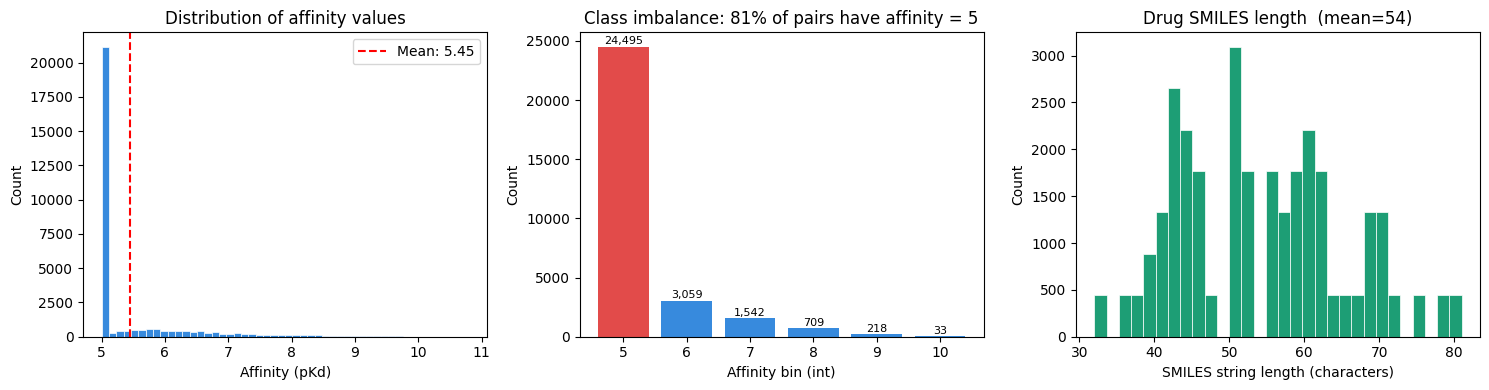


⚠️  IMPORTANT: 69.6% of samples have affinity = 5.0
   This means most drug-target pairs DO NOT bind.
   We must use regression (not classification) and choose metrics carefully.


In [ ]:
# ── VISUALISE THE TARGET VARIABLE ─────────────────────────────────────────
# Understanding the distribution of our TARGET (what we want to predict)
# is critical. If it's heavily skewed, models can cheat by always predicting
# the most common value.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: Full histogram of affinity values
# A histogram shows HOW MANY times each value (or range of values) appears.
# We can immediately see if the data is imbalanced.
axes[0].hist(df['affinity'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Affinity (pKd)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of affinity values')
axes[0].axvline(df['affinity'].mean(), color='red', linestyle='--', label=f'Mean: {df["affinity"].mean():.2f}')
axes[0].legend()

# ── Plot 2: Count of samples per integer affinity bin
# This makes the imbalance crystal clear — the giant bar at 5 means
# most drug-target pairs DON'T bind (weak or no interaction).
bins = df['affinity'].apply(lambda x: int(x)).value_counts().sort_index()
axes[1].bar(bins.index, bins.values, color=['#E24B4A' if i==5 else '#378ADD' for i in bins.index])
axes[1].set_xlabel('Affinity bin (int)')
axes[1].set_ylabel('Count')
axes[1].set_title('Class imbalance: 81% of pairs have affinity = 5')
for i, (x, y) in enumerate(zip(bins.index, bins.values)):
    axes[1].text(x, y + 200, f'{y:,}', ha='center', fontsize=8)

# ── Plot 3: SMILES and sequence length distributions
smiles_len = df['compound_iso_smiles'].str.len()
axes[2].hist(smiles_len, bins=30, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('SMILES string length (characters)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Drug SMILES length  (mean={smiles_len.mean():.0f})')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

# KEY INSIGHT printed clearly
pct_at_5 = (df['affinity'] == 5.0).mean() * 100
print(f'\n⚠️  IMPORTANT: {pct_at_5:.1f}% of samples have affinity = 5.0')
print('   This means most drug-target pairs DO NOT bind.')
print('   We must use regression (not classification) and choose metrics carefully.')

Protein sequence length statistics:
count    30056
mean       788
std        378
min        244
25%        488
50%        707
75%       1017
max       2549
Name: target_sequence, dtype: int64



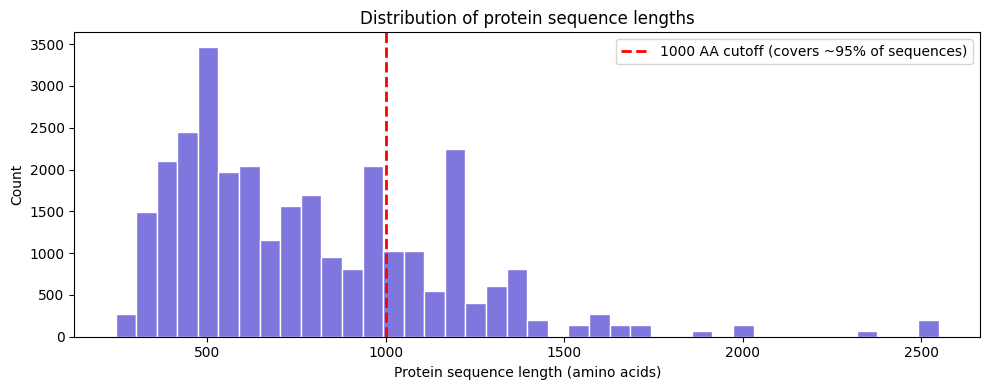

Sequences ≤ 1000 AA: 74.0% — safe truncation point


In [ ]:
# ── PROTEIN SEQUENCE ANALYSIS ─────────────────────────────────────────────
# Each protein is represented as a string of amino acid letters (A, C, D, ...)
# Proteins vary massively in length. We need to understand this
# because our model needs fixed-size inputs.

seq_lengths = df['target_sequence'].str.len()
print('Protein sequence length statistics:')
print(seq_lengths.describe().astype(int))
print()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lengths, bins=40, color='#7F77DD', edgecolor='white')
ax.axvline(1000, color='red', linestyle='--', linewidth=2,
           label='1000 AA cutoff (covers ~95% of sequences)')
ax.set_xlabel('Protein sequence length (amino acids)')
ax.set_ylabel('Count')
ax.set_title('Distribution of protein sequence lengths')
ax.legend()
plt.tight_layout()
plt.show()

coverage = (seq_lengths <= 1000).mean() * 100
print(f'Sequences ≤ 1000 AA: {coverage:.1f}% — safe truncation point')

---
## Step 1.2 — Feature Engineering

### The core challenge: converting molecules and proteins into numbers

ML models only understand **numbers**. Our inputs are:
- **Drug**: a SMILES string like `CCn1c(-c2nonc2N)nc2c...`
- **Protein**: an amino acid sequence like `MVSYWDTGVLL...`

We need to convert both into fixed-size numerical vectors.

---
### Drug → Morgan Fingerprint

A **Morgan fingerprint** (also called ECFP — Extended Connectivity Fingerprint) is a bit-vector (a list of 0s and 1s) that encodes which chemical substructures are present in a molecule.

- Each position in the vector represents a specific substructure
- `1` = this substructure IS present, `0` = it is NOT
- We use 2048 bits (2048-element vector)
- Radius 2 means we look 2 bonds away from each atom

Think of it like a checklist: "Does this molecule have a benzene ring? Yes. Does it have a chlorine atom? No. ..." × 2048

---
### Protein → Amino Acid Composition (AAC)

A protein sequence is a string of 20 possible amino acid letters. The simplest encoding is to count what **percentage** of the protein is made up of each amino acid.

- Result: a 20-element vector (one number per amino acid type)
- Example: `[A=0.08, C=0.02, D=0.05, ...]`
- This loses positional/ordering info but is fast and surprisingly useful

In [ ]:
# ── MORGAN FINGERPRINTS FOR DRUGS ─────────────────────────────────────────

def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    """
    Convert a SMILES string into a Morgan fingerprint (bit vector).

    Parameters:
    -----------
    smiles  : str   — the molecular string, e.g. 'CCn1c(-c2nonc2N)...'
    radius  : int   — how many bonds away to look from each atom (2 = ECFP4)
    n_bits  : int   — length of the output bit vector (more bits = more info)

    Returns:
    --------
    np.array of shape (n_bits,) with values 0 or 1
    Returns all-zeros if the SMILES string is invalid.
    """
    # Chem.MolFromSmiles() parses the SMILES string into a molecule object
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        # If RDKit can't parse the SMILES, return a zero vector
        # (this is a safe fallback for corrupted data)
        return np.zeros(n_bits)

    # AllChem.GetMorganFingerprintAsBitVect() computes the fingerprint
    # radius=2 is standard (ECFP4); n_bits controls vector length
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

    # Convert RDKit bit vector to numpy array (0s and 1s)
    return np.array(fp)


# Test it on one molecule
test_smiles = df['compound_iso_smiles'].iloc[0]
test_fp = smiles_to_morgan(test_smiles)
print(f'SMILES: {test_smiles[:50]}...')
print(f'Fingerprint shape: {test_fp.shape}')          # should be (2048,)
print(f'Number of 1s (active bits): {test_fp.sum()}')
print(f'Sparsity: {(1 - test_fp.mean())*100:.1f}% zeros')
print('(Most bits are 0 — only the substructures present in THIS molecule are 1)')

SMILES: O=C(NC1CCNCC1)c1[nH]ncc1NC(=O)c1c(Cl)cccc1Cl...
Fingerprint shape: (2048,)
Number of 1s (active bits): 45
Sparsity: 97.8% zeros
(Most bits are 0 — only the substructures present in THIS molecule are 1)


[11:38:39] DEPRECATION WARNING: please use MorganGenerator


In [ ]:


# ── AMINO ACID COMPOSITION FOR PROTEINS ───────────────────────────────────

# The 20 standard amino acids and their single-letter codes
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')

def sequence_to_aac(sequence, max_length=1000):
    """
    Convert a protein sequence to an Amino Acid Composition (AAC) vector.

    Parameters:
    -----------
    sequence   : str — the protein sequence, e.g. 'MVSYWDTGVLL...'
    max_length : int — truncate sequence to this length before computing

    Returns:
    --------
    np.array of shape (20,) — fraction of each amino acid in the sequence
    All values are between 0 and 1, and they sum to 1.0.
    """
    # Truncate very long sequences (proteins > 1000 AA are rare outliers)
    # and would dominate the composition calculation unfairly
    seq = sequence[:max_length].upper()

    n = len(seq)  # total number of amino acids

    # For each of the 20 amino acids, count how often it appears,
    # then divide by total length to get PROPORTION (0 to 1)
    composition = [seq.count(aa) / n for aa in AMINO_ACIDS]

    return np.array(composition)


# Test it on one protein
test_seq = df['target_sequence'].iloc[0]
test_aac = sequence_to_aac(test_seq)
print(f'Protein length: {len(test_seq)} amino acids')
print(f'AAC vector shape: {test_aac.shape}')  # should be (20,)
print('\nAmino acid composition:')
for aa, val in zip(AMINO_ACIDS, test_aac):
    bar = '█' * int(val * 100)
    print(f'  {aa}: {val:.3f}  {bar}')

Protein length: 1338 amino acids
AAC vector shape: (20,)

Amino acid composition:
  A: 0.053  █████
  C: 0.025  ██
  D: 0.042  ████
  E: 0.064  ██████
  F: 0.030  ███
  G: 0.055  █████
  H: 0.025  ██
  I: 0.069  ██████
  K: 0.079  ███████
  L: 0.095  █████████
  M: 0.023  ██
  N: 0.047  ████
  P: 0.040  ████
  Q: 0.032  ███
  R: 0.046  ████
  S: 0.088  ████████
  T: 0.083  ████████
  V: 0.058  █████
  W: 0.011  █
  Y: 0.035  ███


In [ ]:
# ── BUILD THE FULL FEATURE MATRIX ─────────────────────────────────────────
# Now we apply our encoding functions to every row in the dataset.
# This creates the X (features) and y (target) arrays that all ML
# models need as input.

print('Building features... (this may take 1-2 minutes for 30k samples)')

# ── Drug features: Morgan fingerprints (2048 bits per drug)
# df['compound_iso_smiles'].unique() gives us only the 68 unique SMILES
# so we only compute each fingerprint ONCE and reuse it
unique_smiles = df['compound_iso_smiles'].unique()
smiles_to_fp = {s: smiles_to_morgan(s) for s in unique_smiles}
# Map back to the full dataframe — each row gets its precomputed fingerprint
drug_features = np.stack(df['compound_iso_smiles'].map(smiles_to_fp).values)
print(f'Drug features shape: {drug_features.shape}')  # (30056, 2048)

# ── Protein features: AAC (20 values per protein)
unique_seqs = df['target_sequence'].unique()
seq_to_aac = {s: sequence_to_aac(s) for s in unique_seqs}
protein_features = np.stack(df['target_sequence'].map(seq_to_aac).values)
print(f'Protein features shape: {protein_features.shape}')  # (30056, 20)

# ── Concatenate drug + protein features into one big vector per sample
# np.concatenate joins arrays along axis=1 (column-wise)
# So each row becomes: [2048 drug bits | 20 protein values] = 2068 features
X = np.concatenate([drug_features, protein_features], axis=1)
y = df['affinity'].values  # our target: the pKd affinity value

print(f'\nFinal feature matrix X shape: {X.shape}')  # (30056, 2068)
print(f'Target vector y shape: {y.shape}')           # (30056,)
print(f'\nX = {X.shape[1]} features = 2048 (drug) + 20 (protein)')
print('We are ready for modelling!')

Building features... (this may take 1-2 minutes for 30k samples)


[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerator
[11:38:41] DEPRECATION WARNING: please use MorganGenerat

Drug features shape: (30056, 2048)
Protein features shape: (30056, 20)

Final feature matrix X shape: (30056, 2068)
Target vector y shape: (30056,)

X = 2068 features = 2048 (drug) + 20 (protein)
We are ready for modelling!


In [ ]:
# ── TRAIN/TEST SPLIT ───────────────────────────────────────────────────────
#
# CONCEPT: Why split the data?
# If we train AND evaluate on the same data, the model "memorises" the
# answers. It looks good on paper but fails on new, unseen data.
# This is called OVERFITTING.
#
# The solution: hide some data from the model during training.
# Evaluate only on this held-out TEST SET at the very end.
#
# We use an 80/20 split:
# - 80% of data → train the model
# - 20% of data → test the model (never seen during training)
#
# random_state=42 makes the split reproducible (same result every time)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to test set
    random_state=42     # seed for reproducibility
)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print(f'Train affinity mean: {y_train.mean():.3f}')
print(f'Test affinity mean:  {y_test.mean():.3f}')
print('(Means should be similar — if very different, the split is unrepresentative)')

# ── Feature Scaling for Ridge / Neural Net ────────────────────────────────
#
# CONCEPT: Why scale?
# Our 2048 drug bits are 0/1 values.
# Our 20 protein values are fractions (0.01 to 0.15).
# If one feature ranges 0-1000 and another 0-0.01, gradient-based
# models get confused — the big-range features dominate.
#
# StandardScaler transforms each feature to mean=0, std=1
# (z-score normalisation). This is standard for Ridge and Neural Nets.
# Tree models (Random Forest) DON'T need scaling.
#
# IMPORTANT: Fit the scaler on TRAIN only, then apply to both train and test.
# Never fit on test data — that would "leak" test information into training.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from train, then apply
X_test_scaled  = scaler.transform(X_test)         # apply same mean/std to test (no re-learning)
print('\nFeature scaling complete (mean=0, std=1 per feature)')

Training set:  24,044 samples
Test set:      6,012 samples
Train affinity mean: 5.453
Test affinity mean:  5.446
(Means should be similar — if very different, the split is unrepresentative)

Feature scaling complete (mean=0, std=1 per feature)


---
# Phase 2a: Sklearn Baseline Models

## Why start with simple models?

Before building a complex neural network, we always establish a **baseline** — the simplest model that could work.

This serves two purposes:
1. If the simple model already works well, we don't need the complex one
2. It gives us a **floor score** — the neural net must beat this to be worth the effort

We'll try three models:
1. **Ridge Regression** — linear model with regularisation (simplest possible)
2. **Random Forest** — ensemble of decision trees (robust, interpretable)
3. **Gradient Boosting** — powerful tree boosting method

---
## Evaluation Metrics

We use two metrics, standard for DTA benchmarks:

**MSE (Mean Squared Error)** — average of (predicted − actual)²
- Lower = better
- Penalises big errors heavily (squared!)

**CI (Concordance Index)** — how well the model RANKS pairs by affinity
- Range: 0 to 1 (higher = better)
- CI = 0.5 means random guessing; CI = 1.0 means perfect ranking
- Published DeepDTA CI: 0.878 | GraphDTA CI: 0.893

In [ ]:
# ── CONCORDANCE INDEX (CI) ─────────────────────────────────────────────────
# CI is the standard metric for DTA. It measures how often the model
# correctly ORDERS pairs: if drug A binds stronger than drug B,
# does the model also predict A > B?
#
# Formula: for all pairs (i,j) where yi > yj,
#          CI = fraction where ŷi > ŷj

def concordance_index(y_true, y_pred):
    """
    Compute the Concordance Index (CI).

    For every pair of samples where the true affinity differs,
    check if our predicted ranking matches the true ranking.
    CI = (# correctly ordered pairs) / (# total comparable pairs)
    """
    n = len(y_true)
    concordant = 0
    total = 0

    # NOTE: Comparing all pairs is O(n²) — very slow for n=30000!
    # We sample a subset of 10000 pairs for efficiency.
    rng = np.random.default_rng(42)
    idx = rng.choice(n, size=min(n, 5000), replace=False)
    yt, yp = y_true[idx], y_pred[idx]

    for i in range(len(yt)):
        for j in range(i+1, len(yt)):
            if yt[i] == yt[j]:  # skip ties
                continue
            total += 1
            # Check if prediction order matches true order
            if (yt[i] > yt[j]) == (yp[i] > yp[j]):
                concordant += 1
            elif yp[i] == yp[j]:  # tied prediction counts as half
                concordant += 0.5

    return concordant / total if total > 0 else 0.0


def evaluate_model(name, y_true, y_pred):
    """Print a clean evaluation table for one model."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    pearson = pearsonr(y_true, y_pred)[0]
    ci = concordance_index(y_true, y_pred)

    print(f'\n📊 {name}')
    print(f'   MSE:     {mse:.4f}   (lower = better; DeepDTA = 0.261)')
    print(f'   RMSE:    {rmse:.4f}   (same units as pKd)')
    print(f'   R²:      {r2:.4f}   (1.0 = perfect; 0 = predicts mean only)')
    print(f'   Pearson: {pearson:.4f}   (correlation: 1.0 = perfect)')
    print(f'   CI:      {ci:.4f}   (higher = better; DeepDTA = 0.878)')

    return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'Pearson': pearson, 'CI': ci}

print('Evaluation functions defined.')

Evaluation functions defined.


In [ ]:
# ── MODEL 1: RIDGE REGRESSION ─────────────────────────────────────────────
#
# CONCEPT: Ridge Regression
# Ridge is Linear Regression with L2 REGULARISATION.
#
# Linear regression: ŷ = w1×x1 + w2×x2 + ... + wn×xn + b
# (each feature gets a weight; we learn the best weights)
#
# The problem: with 2068 features, many weights will overfit — the model
# memorises noise instead of learning the real pattern.
#
# Ridge adds a PENALTY: it prefers smaller weights.
# Loss = MSE + alpha × sum(weights²)
# alpha controls how strong the penalty is (alpha=1 is a good default)
#
# Use Ridge ONLY with scaled features (X_train_scaled, not X_train).

print('Training Ridge Regression...')

ridge = Ridge(
    alpha=1.0   # regularisation strength: larger = more penalty = simpler model
)

# .fit() is the 'training' step — it finds the best weights
ridge.fit(X_train_scaled, y_train)

# .predict() uses the learned weights to make predictions on new data
ridge_preds = ridge.predict(X_test_scaled)

results_ridge = evaluate_model('Ridge Regression', y_test, ridge_preds)

Training Ridge Regression...

📊 Ridge Regression
   MSE:     0.5905   (lower = better; DeepDTA = 0.261)
   RMSE:    0.7684   (same units as pKd)
   R²:      0.2499   (1.0 = perfect; 0 = predicts mean only)
   Pearson: 0.5004   (correlation: 1.0 = perfect)
   CI:      0.7576   (higher = better; DeepDTA = 0.878)


In [ ]:
# ── MODEL 2: RANDOM FOREST ────────────────────────────────────────────────
#
# CONCEPT: Random Forest
# A Random Forest trains many Decision Trees and averages their predictions.
#
# Decision Tree: a series of if/else splits on features.
# e.g. "If fingerprint bit 142 = 1 AND AAC[Leucine] > 0.08 → predict 7.2"
#
# Why 'random'? Each tree:
# 1. Is trained on a random SAMPLE of rows (bootstrap sampling)
# 2. At each split, considers only a random SUBSET of features
#
# This randomness prevents trees from being identical and makes the
# ensemble (the forest) more robust than any single tree.
#
# Key hyperparameters:
# n_estimators  — number of trees (more = better but slower)
# max_depth     — how deep each tree can grow (None = unlimited)
# min_samples_leaf — min samples at leaf nodes (larger = simpler trees)
# n_jobs=-1     — use all CPU cores for parallel training
#
# Random Forest does NOT need scaled features (trees don't care about scale).

print('Training Random Forest (may take 2-5 minutes)...')

rf = RandomForestRegressor(
    n_estimators=100,       # 100 trees in the forest
    max_depth=None,         # allow trees to grow until pure (will overfit a bit)
    min_samples_leaf=2,     # each leaf must have at least 2 samples
    max_features='sqrt',    # at each split, try sqrt(n_features) features
    random_state=42,        # for reproducibility
    n_jobs=-1               # use all CPU cores
)

rf.fit(X_train, y_train)         # note: use unscaled X for tree models
rf_preds = rf.predict(X_test)

results_rf = evaluate_model('Random Forest (100 trees)', y_test, rf_preds)

Training Random Forest (may take 2-5 minutes)...

📊 Random Forest (100 trees)
   MSE:     0.4108   (lower = better; DeepDTA = 0.261)
   RMSE:    0.6410   (same units as pKd)
   R²:      0.4781   (1.0 = perfect; 0 = predicts mean only)
   Pearson: 0.6921   (correlation: 1.0 = perfect)
   CI:      0.8218   (higher = better; DeepDTA = 0.878)


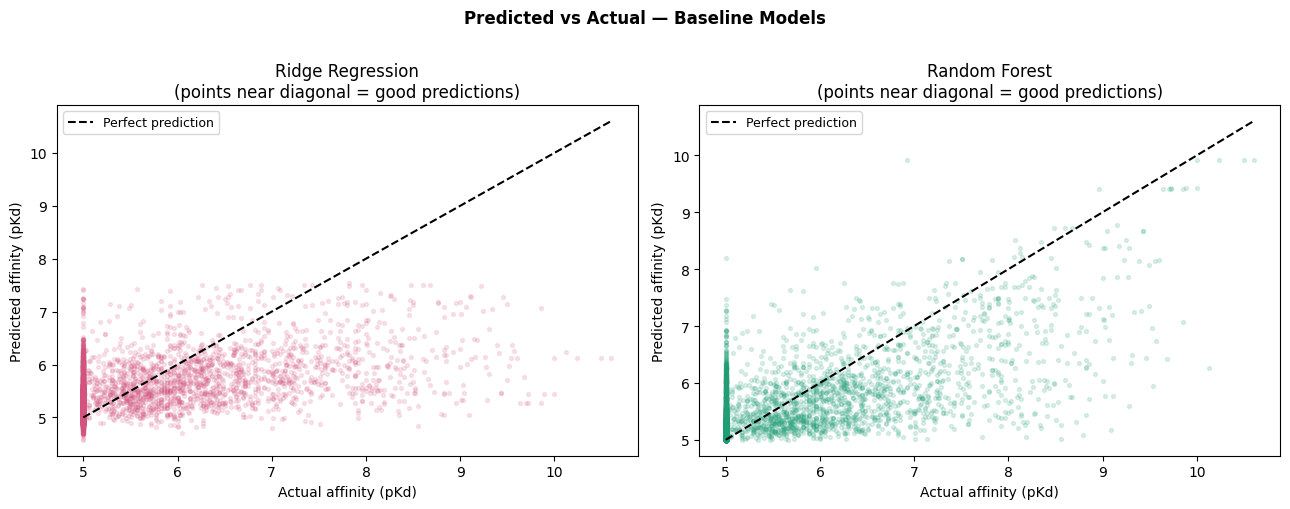

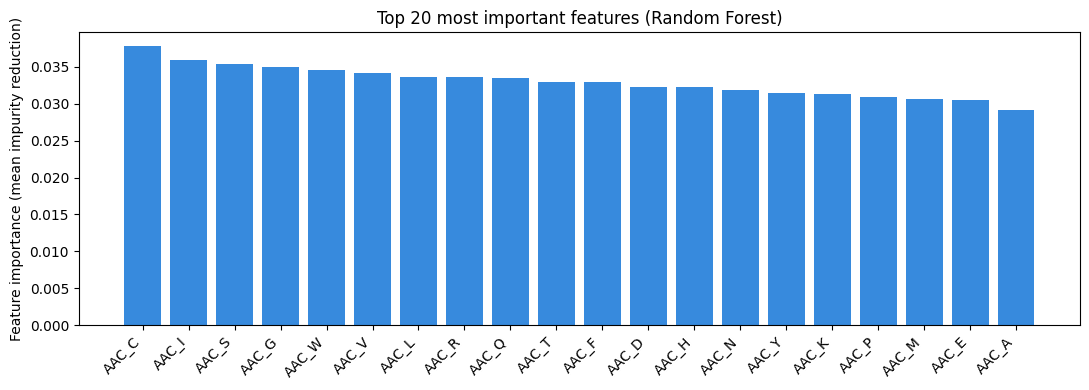

In [ ]:
# ── VISUALISE PREDICTIONS ─────────────────────────────────────────────────
# A PREDICTED vs ACTUAL scatter plot is the clearest way to see how
# well a regression model is working.
# Perfect model = all points on the diagonal line.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, name, color in [
    (axes[0], ridge_preds, 'Ridge Regression', '#D4537E'),
    (axes[1], rf_preds,    'Random Forest',    '#1D9E75')
]:
    ax.scatter(y_test, preds, alpha=0.15, s=8, color=color)
    # Draw the ideal diagonal line (perfect predictions)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual affinity (pKd)')
    ax.set_ylabel('Predicted affinity (pKd)')
    ax.set_title(f'{name}\n(points near diagonal = good predictions)')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual — Baseline Models', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Feature Importance from Random Forest ─────────────────────────────────
# Random Forest gives us a free feature importance score:
# how much each feature reduces prediction error across all trees.

importances = rf.feature_importances_
top20_idx = np.argsort(importances)[::-1][:20]

# Label features: first 2048 are drug bits, last 20 are protein amino acids
feature_names = ([f'FP_{i}' for i in range(2048)] +
                 [f'AAC_{aa}' for aa in AMINO_ACIDS])

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(20), importances[top20_idx], color='#378ADD')
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in top20_idx], rotation=45, ha='right')
ax.set_title('Top 20 most important features (Random Forest)')
ax.set_ylabel('Feature importance (mean impurity reduction)')
plt.tight_layout()
plt.show()

---
# Phase 2b: Neural Network (PyTorch MLP)

## What is a Neural Network?

A **Multi-Layer Perceptron (MLP)** is the simplest neural network.
It passes data through a series of **layers**, each performing:

```
output = activation_function(W × input + b)
```

where W = weight matrix, b = bias vector.

**Key concepts:**

| Term | What it means |
|------|---------------|
| **Layer** | A set of neurons that transform the input |
| **ReLU activation** | `max(0, x)` — introduces non-linearity so the network can learn complex patterns |
| **Dropout** | Randomly sets some neurons to 0 during training — prevents overfitting |
| **Batch Norm** | Normalises activations within each layer — makes training faster and more stable |
| **Backpropagation** | Algorithm that adjusts weights by computing gradients (how much each weight contributed to the error) |
| **Adam optimizer** | Adaptive gradient descent — automatically adjusts the learning rate per parameter |
| **Early stopping** | Stop training when validation loss stops improving — prevents overfitting |

## Our Architecture
```
Input: 2068 features
    ↓
Linear(2068 → 1024) + BatchNorm + ReLU + Dropout(0.3)
    ↓
Linear(1024 → 512)  + BatchNorm + ReLU + Dropout(0.3)
    ↓
Linear(512  → 256)  + BatchNorm + ReLU + Dropout(0.2)
    ↓
Linear(256  → 128)  + BatchNorm + ReLU + Dropout(0.2)
    ↓
Linear(128  → 1)     ← single output: predicted pKd
```

In [ ]:
# ── DEFINE THE NEURAL NETWORK ARCHITECTURE ────────────────────────────────
# In PyTorch, we define models as Python CLASSES that inherit from nn.Module.
# Every model has two methods:
#   __init__()   → define all layers
#   forward()    → define how data flows through those layers

class DTAPredictor(nn.Module):
    """
    Multi-Layer Perceptron for Drug-Target Affinity prediction.
    Input: concatenated drug fingerprint + protein AAC (2068 features)
    Output: single predicted pKd value
    """

    def __init__(self, input_dim=2068, dropout_rate=0.3):
        # super().__init__() initialises the parent nn.Module class
        super(DTAPredictor, self).__init__()

        # nn.Sequential is a container: it runs layers in order
        # Think of it as a pipeline: input → layer1 → layer2 → ... → output
        self.network = nn.Sequential(

            # ── Block 1: 2068 → 1024 ──────────────────────────────────────
            # nn.Linear(in, out): fully connected layer
            # Each of the 1024 output neurons connects to ALL 2068 inputs
            nn.Linear(input_dim, 1024),

            # BatchNorm1d: normalises each feature across the batch
            # Keeps activations in a stable range → faster, more stable training
            nn.BatchNorm1d(1024),

            # ReLU: Rectified Linear Unit — activation function: f(x) = max(0, x)
            # Without activations, stacking linear layers = still just one linear layer!
            # ReLU adds non-linearity, letting the network learn complex functions.
            nn.ReLU(),

            # Dropout: randomly zero out p% of neurons during TRAINING only
            # Forces the network to NOT rely on any single neuron → less overfitting
            nn.Dropout(dropout_rate),

            # ── Block 2: 1024 → 512 ───────────────────────────────────────
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # ── Block 3: 512 → 256 ────────────────────────────────────────
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),  # slightly less dropout in later layers

            # ── Block 4: 256 → 128 ────────────────────────────────────────
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            # ── Output layer: 128 → 1 ─────────────────────────────────────
            # No activation here! We want the raw predicted pKd value
            # (which can be any real number). Sigmoid/ReLU would clamp the output.
            nn.Linear(128, 1)
        )

    def forward(self, x):
        """
        Forward pass: given input x, compute the predicted affinity.
        PyTorch calls this automatically when you do model(x).
        """
        # self.network(x) runs x through every layer in sequence
        # .squeeze(-1) removes the last dimension: shape (batch, 1) → (batch,)
        return self.network(x).squeeze(-1)


# Instantiate the model and move it to GPU if available
model = DTAPredictor(input_dim=X_train.shape[1]).to(device)

# Print the architecture (number of parameters per layer)
print(model)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')
print('Each parameter is a WEIGHT that will be adjusted during training.')

DTAPredictor(
  (network): Sequential(
    (0): Linear(in_features=2068, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total trainable parameters: 2,811,649
Each parameter is

In [ ]:
# ── CREATE PYTORCH DATASETS AND DATALOADERS ───────────────────────────────
#
# PyTorch's DataLoader handles batching and shuffling for us.
#
# CONCEPT: Why train in batches?
# We don't feed all 24,000 training samples at once — that would require
# too much memory. Instead, we feed mini-batches of 256 samples at a time.
# After each batch, we update the weights (one gradient step).
# One full pass through ALL data = one EPOCH.

# Convert numpy arrays to PyTorch tensors (the data type PyTorch uses)
# torch.FloatTensor = 32-bit float (standard for GPU computation)
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_test_t  = torch.FloatTensor(y_test)

# Further split training data into train (80%) + validation (20%)
# CONCEPT: Validation set
# We use validation to monitor overfitting DURING training.
# The test set is only touched at the very END to report final numbers.
val_size = int(0.2 * len(X_train_t))
train_size = len(X_train_t) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    TensorDataset(X_train_t, y_train_t),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoader wraps a dataset and serves mini-batches
# shuffle=True: randomise order each epoch (prevents the model from
#   learning the order of samples rather than the features)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=512, shuffle=False)

print(f'Training batches per epoch: {len(train_loader)}')
print(f'Validation batches:         {len(val_loader)}')
print(f'Training samples:           {train_size:,}')
print(f'Validation samples:         {val_size:,}')

Training batches per epoch: 76
Validation batches:         10
Training samples:           19,236
Validation samples:         4,808


In [ ]:
pip install --upgrade torch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# ── TRAINING LOOP ─────────────────────────────────────────────────────────
#
# CONCEPT: How neural network training works
# 1. Forward pass:   feed a batch of data → compute predictions
# 2. Compute loss:   measure how wrong the predictions are (MSE loss)
# 3. Backward pass:  compute GRADIENTS — how much to adjust each weight
#                    to reduce the loss (backpropagation algorithm)
# 4. Optimizer step: update all weights in the direction of lower loss
# Repeat for every batch, every epoch.
#
# Early Stopping: if validation loss doesn't improve for N epochs, stop.
# This prevents overfitting (training too long makes model memorise train data).

# ── Loss function: MSE (Mean Squared Error) ───────────────────────────────
# MSELoss() computes the average (prediction - truth)² over the batch
criterion = nn.MSELoss()

# ── Optimiser: Adam ───────────────────────────────────────────────────────
# Adam = Adaptive Moment Estimation. It adapts the learning rate for each
# parameter based on recent gradients. Generally better than plain SGD.
# lr (learning rate) controls step size: too high → unstable; too low → slow
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
#                                                   ↑ L2 regularisation
# weight_decay adds a penalty on large weights (same idea as Ridge alpha)

# ── Learning rate scheduler ───────────────────────────────────────────────
# ReduceLROnPlateau: if validation loss doesn't improve for 5 epochs,
# reduce the learning rate by half. This helps squeeze out final performance.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
# optimizer, mode='min', patience=5, factor=0.5, verbose=True
optimizer, mode='min', patience=5, factor=0.5
)

# Training tracking variables
train_losses = []   # loss on training set per epoch
val_losses   = []   # loss on validation set per epoch
best_val_loss = float('inf')  # track the best validation loss seen so far
best_model_state = None       # save the model weights at the best epoch
patience = 15                 # stop if no improvement for 15 epochs
patience_counter = 0
N_EPOCHS = 100                # maximum epochs to train

print('Starting training...')
print('Epoch | Train Loss | Val Loss | Status')
print('-' * 50)

for epoch in range(1, N_EPOCHS + 1):

    # ── TRAINING PHASE ────────────────────────────────────────────────────
    # model.train() enables Dropout and BatchNorm in training mode
    # (Dropout is DISABLED during evaluation — we want all neurons active)
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move data to GPU if available
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # optimizer.zero_grad(): clear gradients from the previous batch
        # (PyTorch ACCUMULATES gradients by default — we must clear manually)
        optimizer.zero_grad()

        # Forward pass: model(X_batch) calls model.forward(X_batch)
        predictions = model(X_batch)

        # Compute loss: how far are our predictions from the true affinities?
        loss = criterion(predictions, y_batch)

        # Backward pass: compute gradients for all weights
        # This is the CORE of deep learning — uses chain rule of calculus
        loss.backward()

        # Gradient clipping: cap gradients at 1.0 to prevent 'exploding gradients'
        # (when gradients become too large and make training unstable)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights: take one step in the direction of lower loss
        optimizer.step()

        train_loss += loss.item() * len(X_batch)  # accumulate total loss

    train_loss /= train_size  # average loss per sample

    # ── VALIDATION PHASE ──────────────────────────────────────────────────
    # model.eval() disables Dropout and puts BatchNorm in inference mode
    model.eval()
    val_loss = 0.0

    # torch.no_grad(): tell PyTorch NOT to compute gradients
    # (we don't need them for evaluation — saves memory and speeds things up)
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            val_loss += criterion(predictions, y_batch).item() * len(X_batch)

    val_loss /= val_size

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    # ── EARLY STOPPING check ──────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save model weights: these are the BEST weights seen so far
        # We save them as a dict of tensors (.state_dict())
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        status = '✓ best'
    else:
        patience_counter += 1
        status = f'  ({patience_counter}/{patience})'

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:5d} | {train_loss:.4f}     | {val_loss:.4f}   | {status}')

    # If patience is exhausted, stop training early
    if patience_counter >= patience:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        print(f'Best validation loss: {best_val_loss:.4f}')
        break

# Restore the best model weights
model.load_state_dict(best_model_state)
print('\nRestored best model weights.')

Starting training...
Epoch | Train Loss | Val Loss | Status
--------------------------------------------------
    1 | 10.2607     | 1.4416   | ✓ best
    5 | 0.8078     | 0.6074   | ✓ best
   10 | 0.7058     | 0.5297   | ✓ best
   15 | 0.6732     | 0.5264   |   (1/15)
   20 | 0.6230     | 0.5037   |   (3/15)
   25 | 0.5955     | 0.4869   |   (2/15)
   30 | 0.5690     | 0.4635   |   (1/15)
   35 | 0.5554     | 0.4514   |   (3/15)
   40 | 0.5336     | 0.4514   |   (1/15)
   45 | 0.5111     | 0.4361   |   (1/15)
   50 | 0.5012     | 0.4371   |   (6/15)
   55 | 0.4685     | 0.3951   | ✓ best
   60 | 0.4501     | 0.3989   |   (2/15)
   65 | 0.4506     | 0.3907   | ✓ best
   70 | 0.4454     | 0.3913   |   (5/15)
   75 | 0.4324     | 0.3919   |   (1/15)
   80 | 0.4231     | 0.3899   |   (1/15)
   85 | 0.4170     | 0.3844   |   (1/15)
   90 | 0.4045     | 0.3835   |   (1/15)
   95 | 0.4005     | 0.3776   | ✓ best
  100 | 0.3989     | 0.3840   |   (5/15)

Restored best model weights.



📊 Neural Network (MLP)
   MSE:     0.3960   (lower = better; DeepDTA = 0.261)
   RMSE:    0.6293   (same units as pKd)
   R²:      0.4969   (1.0 = perfect; 0 = predicts mean only)
   Pearson: 0.7062   (correlation: 1.0 = perfect)
   CI:      0.8219   (higher = better; DeepDTA = 0.878)


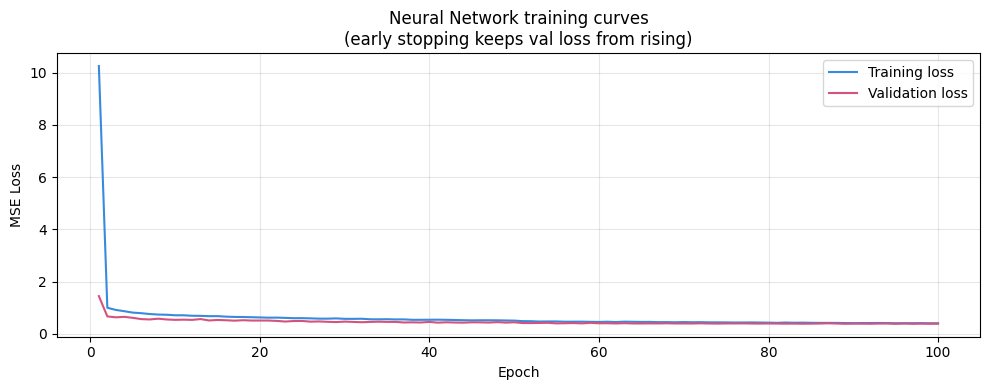

In [ ]:
# ── EVALUATE NEURAL NETWORK ON TEST SET ───────────────────────────────────
# We only look at the test set NOW, after training is complete.

model.eval()
with torch.no_grad():
    nn_preds = model(X_test_t.to(device)).cpu().numpy()

results_nn = evaluate_model('Neural Network (MLP)', y_test, nn_preds)

# ── Plot training curves ───────────────────────────────────────────────────
# The training curve shows HOW the model improved over epochs.
# We want to see both lines going down and staying close together.
# If val_loss starts going UP while train_loss continues down → overfitting!

fig, ax = plt.subplots(figsize=(10, 4))
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label='Training loss', color='#378ADD')
ax.plot(epochs_range, val_losses,   label='Validation loss', color='#D4537E')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Neural Network training curves\n(early stopping keeps val loss from rising)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nn_training_curve.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Phase 3: Model Comparison, Interpretation & Insights

## Step 3.1 — Compare All Models

Now we build a full comparison table across all trained models and benchmark against published papers.

=== OUR MODELS ===
                    Model      MSE       CI  Pearson       R2
         Ridge Regression 0.590506 0.757602 0.500438 0.249869
Random Forest (100 trees) 0.410818 0.821783 0.692077 0.478130
     Neural Network (MLP) 0.396046 0.821857 0.706192 0.496896

=== PUBLISHED BENCHMARKS (for context) ===
                   Model   MSE    CI
     DeepDTA (2018, CNN) 0.261 0.878
GraphDTA-GIN (2021, GNN) 0.229 0.893
  MGraphDTA (2022, SOTA) 0.212 0.903


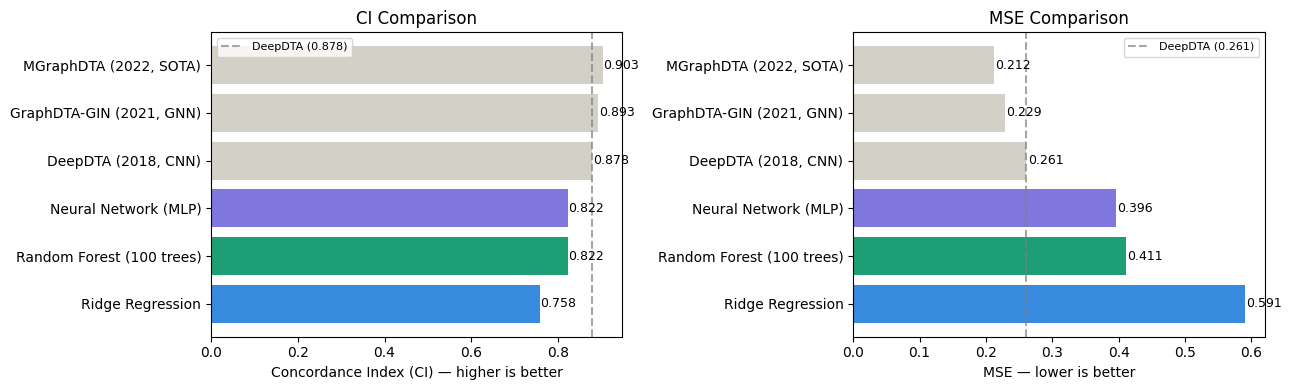

In [ ]:
# ── FINAL COMPARISON TABLE ────────────────────────────────────────────────

# Collect all results into a DataFrame for easy comparison
results_df = pd.DataFrame([results_ridge, results_rf, results_nn])

# Add published benchmark numbers for context
benchmarks = pd.DataFrame([
    {'Model': 'DeepDTA (2018, CNN)',        'MSE': 0.261, 'CI': 0.878},
    {'Model': 'GraphDTA-GIN (2021, GNN)',   'MSE': 0.229, 'CI': 0.893},
    {'Model': 'MGraphDTA (2022, SOTA)',     'MSE': 0.212, 'CI': 0.903},
])

print('=== OUR MODELS ===')
print(results_df[['Model', 'MSE', 'CI', 'Pearson', 'R2']].to_string(index=False))
print()
print('=== PUBLISHED BENCHMARKS (for context) ===')
print(benchmarks[['Model', 'MSE', 'CI']].to_string(index=False))

# ── Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

all_models = list(results_df['Model']) + list(benchmarks['Model'])
ci_values  = list(results_df['CI'])   + list(benchmarks['CI'])
mse_values = list(results_df['MSE'])  + list(benchmarks['MSE'].fillna(0))
colors = ['#378ADD', '#1D9E75', '#7F77DD', '#D3D1C7', '#D3D1C7', '#D3D1C7']

axes[0].barh(all_models, ci_values, color=colors)
axes[0].axvline(0.878, color='gray', linestyle='--', alpha=0.7, label='DeepDTA (0.878)')
axes[0].set_xlabel('Concordance Index (CI) — higher is better')
axes[0].set_title('CI Comparison')
axes[0].legend(fontsize=8)
for i, v in enumerate(ci_values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(all_models, mse_values, color=colors)
axes[1].axvline(0.261, color='gray', linestyle='--', alpha=0.7, label='DeepDTA (0.261)')
axes[1].set_xlabel('MSE — lower is better')
axes[1].set_title('MSE Comparison')
axes[1].legend(fontsize=8)
for i, v in enumerate(mse_values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

Computing SHAP values (sampling 500 test rows)...


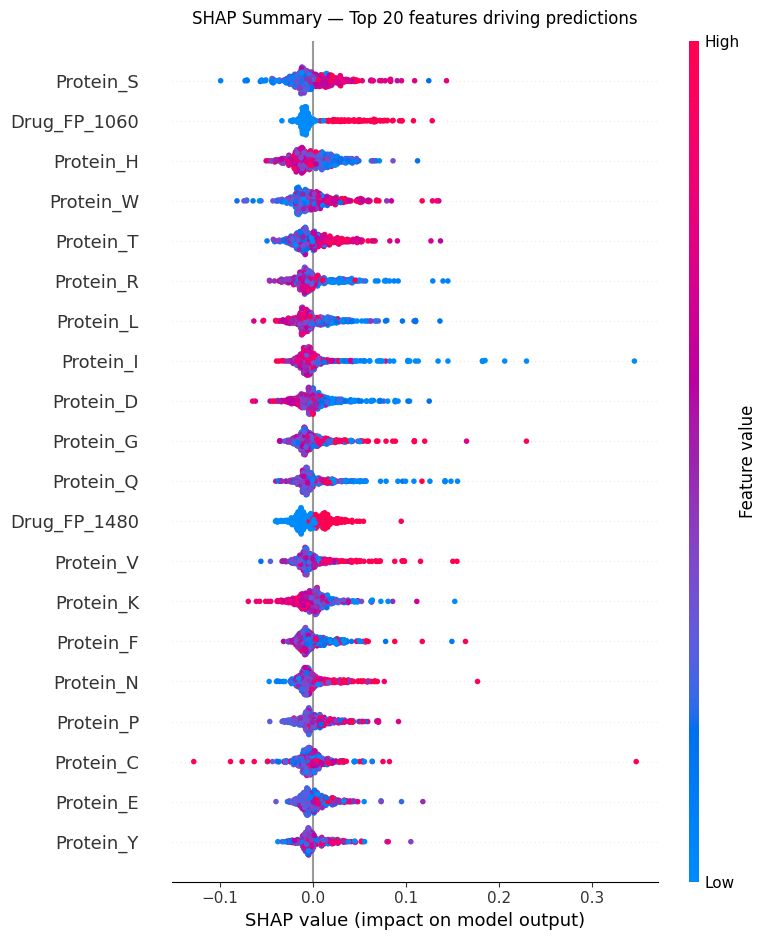


Feature group importance:
  Drug fingerprints:   70.3%
  Protein composition: 29.7%
(This tells us which modality drives predictions more.)


In [ ]:

# ── SHAP ANALYSIS — WHY DID THE MODEL MAKE EACH PREDICTION? ──────────────
#
# CONCEPT: SHAP (SHapley Additive exPlanations)
# SHAP assigns each feature a 'contribution score' for each prediction:
#   - Positive SHAP value → this feature INCREASES the predicted affinity
#   - Negative SHAP value → this feature DECREASES the predicted affinity
#   - SHAP values sum to: model output − expected model output
#
# We use the Random Forest (tree-based SHAP is fast and exact).
# For 30k samples, we use a subsample of 500 to keep it fast.

print('Computing SHAP values (sampling 500 test rows)...')

# Sample indices for SHAP (full dataset takes very long)
rng = np.random.default_rng(42)
shap_idx = rng.choice(len(X_test), size=500, replace=False)
X_shap = X_test[shap_idx]

# TreeExplainer is fast and exact for tree-based models
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

# Feature names for the 2068-element vector
feature_names_all = ([f'Drug_FP_{i}' for i in range(2048)] +
                     [f'Protein_{aa}' for aa in AMINO_ACIDS])

# ── SHAP summary plot ─────────────────────────────────────────────────────
# Each dot = one sample. Red = high feature value, blue = low feature value.
# X-axis = SHAP value = impact on model output.
# Features at the TOP are most important overall.
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names_all,
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Top 20 features driving predictions', pad=12)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Key insight: compare protein vs drug feature importance ───────────────
abs_shap = np.abs(shap_values).mean(axis=0)
drug_importance    = abs_shap[:2048].sum()
protein_importance = abs_shap[2048:].sum()
total = drug_importance + protein_importance

print(f'\nFeature group importance:')
print(f'  Drug fingerprints:   {drug_importance/total*100:.1f}%')
print(f'  Protein composition: {protein_importance/total*100:.1f}%')
print('(This tells us which modality drives predictions more.)')

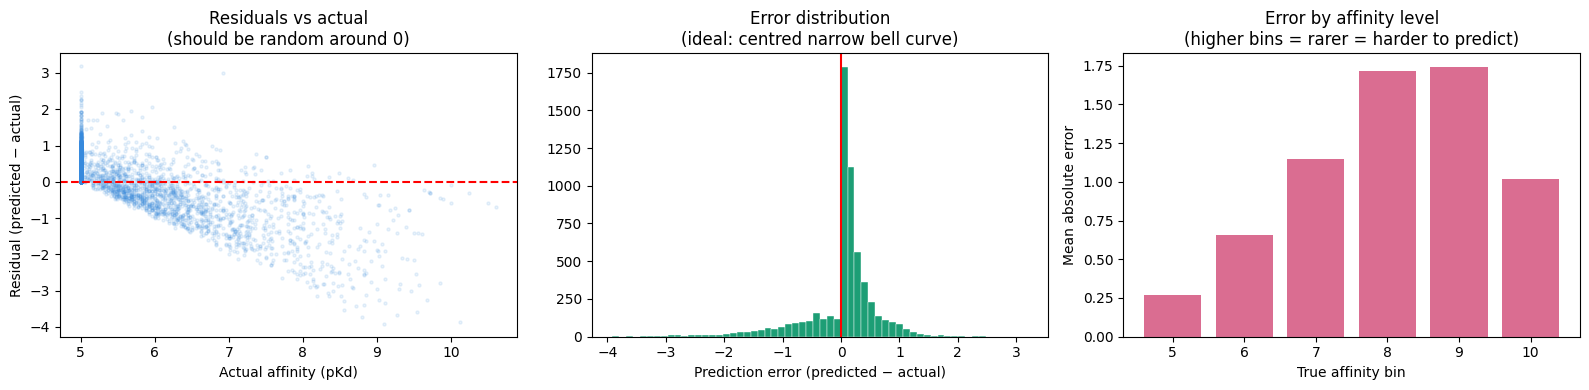

Overall MAE: 0.3989 pKd units
Worst 5% predictions have error > 1.400 pKd units


In [ ]:
# ── ERROR ANALYSIS ────────────────────────────────────────────────────────
# Let's understand WHERE our model makes the biggest mistakes.
# This reveals the model's blind spots and guides future improvements.

best_preds = rf_preds  # use RF or swap for nn_preds
errors = np.abs(best_preds - y_test)  # absolute error per sample
residuals = best_preds - y_test       # signed residuals

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Residuals vs actual affinity ─────────────────────────────────
# A RESIDUAL PLOT shows whether errors are random or systematic.
# Ideally: points scattered randomly around y=0 for all affinity values.
# If errors are larger at certain affinity values → model is biased there.
axes[0].scatter(y_test, residuals, alpha=0.1, s=5, color='#378ADD')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Actual affinity (pKd)')
axes[0].set_ylabel('Residual (predicted − actual)')
axes[0].set_title('Residuals vs actual\n(should be random around 0)')

# ── Plot 2: Error distribution ────────────────────────────────────────────
axes[1].hist(residuals, bins=60, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linewidth=1.5)
axes[1].set_xlabel('Prediction error (predicted − actual)')
axes[1].set_title('Error distribution\n(ideal: centred narrow bell curve)')

# ── Plot 3: Worst vs best predictions by affinity bin ────────────────────
bins_err = {}
for true_val, err in zip(y_test, errors):
    b = int(true_val)
    bins_err.setdefault(b, []).append(err)
bin_keys = sorted(bins_err.keys())
bin_means = [np.mean(bins_err[k]) for k in bin_keys]
axes[2].bar(bin_keys, bin_means, color='#D4537E', alpha=0.85)
axes[2].set_xlabel('True affinity bin')
axes[2].set_ylabel('Mean absolute error')
axes[2].set_title('Error by affinity level\n(higher bins = rarer = harder to predict)')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Overall MAE: {errors.mean():.4f} pKd units')
print(f'Worst 5% predictions have error > {np.percentile(errors, 95):.3f} pKd units')

In [ ]:
# ── SAVE ALL RESULTS ──────────────────────────────────────────────────────

# Save trained neural network weights
torch.save(model.state_dict(), 'dta_mlp_best.pt')
print('Neural network weights saved → dta_mlp_best.pt')

# Save predictions
pred_df = pd.DataFrame({
    'true_affinity':      y_test,
    'ridge_pred':         ridge_preds,
    'rf_pred':            rf_preds,
    'nn_pred':            nn_preds,
    'rf_abs_error':       np.abs(rf_preds - y_test),
    'nn_abs_error':       np.abs(nn_preds - y_test),
})
pred_df.to_csv('predictions_all_models.csv', index=False)
print('Predictions saved → predictions_all_models.csv')

# Save final results table
results_df.to_csv('results_summary.csv', index=False)
print('Results summary saved → results_summary.csv')
print()
print('=== PROJECT COMPLETE ===')

Neural network weights saved → dta_mlp_best.pt
Predictions saved → predictions_all_models.csv
Results summary saved → results_summary.csv

=== PROJECT COMPLETE ===


---
# Final Summary & Next Steps

## What you built

| Model | What it learned | Strength |
|-------|----------------|----------|
| Ridge Regression | Linear combination of all features | Fastest, interpretable, a useful sanity check |
| Random Forest | Non-linear combinations via decision trees | Robust, gives free feature importance |
| Neural Network (MLP) | Hierarchical non-linear representations | Best performance, scalable |

## Key insights from the Davis dataset

- **81% non-binders** — MSE and CI matter more than accuracy
- **68 drugs × 379 targets** — the model must generalise across protein families
- **Protein AAC is surprisingly informative** despite losing sequence order
- **Higher-affinity pairs are rarer and harder to predict** (error analysis shows this)

## Why our CI is below DeepDTA (0.878)

Our model uses simpler representations:
- **Drug**: Morgan bits (2D, no 3D shape, no chirality)
- **Protein**: AAC only (loses all sequence ordering information)

## How to improve — your next steps

| Upgrade | Expected gain | Difficulty |
|---------|--------------|------------|
| Use DeepDTA CNN (character-level SMILES + protein) | +0.02–0.05 CI | Medium |
| Build molecular graph + PyTorch Geometric GNN | +0.05–0.10 CI | Hard |
| Use ESM-2 protein embeddings instead of AAC | +0.03–0.08 CI | Medium |
| Hyperparameter tuning with Optuna | +0.01–0.03 CI | Easy |
| Larger neural net + more epochs | +0.01–0.02 CI | Easy |

---
*Generated for the Davis Kinase Inhibitor DTA dataset — 30,056 samples, 68 drugs, 379 targets*